<a href="https://colab.research.google.com/github/gracenguyn/Project3/blob/main/Copy_of_DiD_Cleaningipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import kagglehub
import geopandas as gpd
import datetime as dt

# Download latest version
path = kagglehub.dataset_download("alexgude/california-traffic-collision-data-from-switrs")

print("Path to dataset files:", path)

100%|██████████| 1.50G/1.50G [00:54<00:00, 29.7MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/alexgude/california-traffic-collision-data-from-switrs/versions/6


## Data Cleaning

### Grab data for synethic control

In [ ]:
import sqlite3
import os

# The 'path' variable is already defined from the kagglehub.dataset_download call
# in the first cell, which correctly points to the dataset's directory.
# We should use that path instead of a hardcoded incorrect one.
db_file_path = os.path.join(path, 'switrs.sqlite') # Changed path_to_dataset_dir to path
conn = sqlite3.connect(db_file_path)

collisions = pd.read_sql_query("""
    SELECT case_id, collision_date, county_city_location, collision_severity, county_location, population, weather_1, primary_collision_factor, pcf_violation_category, hit_and_run, type_of_collision, road_condition_1, road_surface, lighting, alcohol_involved, latitude, longitude
    FROM collisions
    WHERE collision_date >= '2010-01-01' AND collision_date <= '2016-12-31';
""", conn)

collisions.head()

,case_id,collision_date,county_city_location,collision_severity,county_location,population,weather_1,primary_collision_factor,pcf_violation_category,hit_and_run,type_of_collision,road_condition_1,road_surface,lighting,alcohol_involved,latitude,longitude
0,4391974,2010-01-06,1942,property damage only,los angeles,>250000,clear,other than driver,other than driver (or pedestrian),not hit and run,hit object,normal,dry,daylight,NaN,NaN,NaN
1,4392005,2010-01-19,3300,fatal,riverside,unincorporated,cloudy,vehicle code violation,improper turning,not hit and run,hit object,normal,dry,dark with street lights,1.0,34.01847,-117.50958
2,4392006,2010-01-13,1935,fatal,los angeles,50000 to 100000,raining,vehicle code violation,traffic signals and signs,not hit and run,broadside,normal,wet,dark with street lights,NaN,NaN,NaN
3,4392007,2010-01-15,1942,fatal,los angeles,>250000,clear,vehicle code violation,pedestrian violation,felony,pedestrian,normal,dry,dark with street lights,1.0,NaN,NaN
4,4392008,2010-01-03,1942,fatal,los angeles,>250000,cloudy,vehicle code violation,traffic signals and signs,not hit and run,broadside,normal,dry,daylight,NaN,NaN,NaN


In [ ]:
print(collisions.shape)
print(collisions.columns)

(2929213, 17)
Index(['case_id', 'collision_date', 'county_city_location',
       'collision_severity', 'county_location', 'population', 'weather_1',
       'primary_collision_factor', 'pcf_violation_category', 'hit_and_run',
       'type_of_collision', 'road_condition_1', 'road_surface', 'lighting',
       'alcohol_involved', 'latitude', 'longitude'],
      dtype='object')


##Label Cities (NCIC Codes)

In [ ]:
NCIC = pd.read_csv('NCIC Code Jurisdiction List_04242023 - Sheet1.csv')

In [ ]:
#combine data sets
collisions_coded = pd.merge(collisions, NCIC, how='left', left_on='county_city_location', right_on='Code')

In [ ]:
sf = collisions_coded[collisions_coded['Agency'] == 'San Francisco']
sf = sf[sf['collision_date'] >= '2013-11-01']
sf = sf[sf['collision_date'] <= '2013-12-31']
sf_per_day = sf.groupby('collision_date').size()
sf_per_day

,0
collision_date,
2013-11-01,8
2013-11-02,3
2013-11-03,3
2013-11-04,8
2013-11-05,6
2013-11-06,6
2013-11-07,7
2013-11-08,7
2013-11-09,7


In [ ]:
#get value counts of codes
print(collisions_coded['Code'].value_counts())

Code
1942    354735
1900    107641
3711     63027
3400     58781
0109     47334
         ...  
1307         1
1010         1
4707         1
1303         1
1204         1
Name: count, Length: 498, dtype: int64


In [ ]:
#drop codes for Los Angles, San Diego, San Jose, and Fremont
collisions_ca = collisions_coded[~collisions_coded['Code'].isin(['1942', '3711', '4313', '0105'])]

In [ ]:
print(collisions_ca['Code'].value_counts())

Code
1900    107641
3400     58781
0109     47334
1941     45573
3801     44833
         ...  
4707         1
1504         1
1307         1
1303         1
1204         1
Name: count, Length: 494, dtype: int64


### Label treatment by city and time


In [ ]:
collisions_ca.columns

Index(['case_id', 'collision_date', 'county_city_location',
       'collision_severity', 'county_location', 'population', 'weather_1',
       'primary_collision_factor', 'pcf_violation_category', 'hit_and_run',
       'type_of_collision', 'road_condition_1', 'road_surface', 'lighting',
       'alcohol_involved', 'latitude', 'longitude', 'CntyCode', 'County',
       'Code', 'Agency', 'Start', 'End'],
      dtype='object')

In [ ]:
collisions_ca['collision_date'] = pd.to_datetime(collisions_ca['collision_date'])
collisions_ca['year_month'] = collisions_ca['collision_date'].dt.to_period('M')

/tmp/ipykernel_40725/3713592967.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  collisions_ca['collision_date'] = pd.to_datetime(collisions_ca['collision_date'])
/tmp/ipykernel_40725/3713592967.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  collisions_ca['year_month'] = collisions_ca['collision_date'].dt.to_period('M')


In [ ]:
print(collisions_ca.shape)
print(collisions_ca.columns)

(2453441, 24)
Index(['case_id', 'collision_date', 'county_city_location',
       'collision_severity', 'county_location', 'population', 'weather_1',
       'primary_collision_factor', 'pcf_violation_category', 'hit_and_run',
       'type_of_collision', 'road_condition_1', 'road_surface', 'lighting',
       'alcohol_involved', 'latitude', 'longitude', 'CntyCode', 'County',
       'Code', 'Agency', 'Start', 'End', 'year_month'],
      dtype='object')


In [ ]:
#Get rid of Sheriff's Departments in Agencys
collisions_ca = collisions_ca[~collisions_ca['Agency'].str.contains('Sheriff', na=False)]
collisions_ca = collisions_ca[~collisions_ca['Agency'].str.contains('Police', na=False)]

print(collisions_ca['Agency'].unique())

['Lakewood' 'Rancho Cucamonga' 'Fresno' 'South El Monte' 'Barstow'
 'Pomona' 'Walnut' 'Hanford' 'Los Gatos' nan 'Ontario' 'Brisbane'
 'Huntington Beach' 'Fullerton' 'Tehachapi' 'Compton' 'Costa Mesa'
 'Sacramento' 'Long Beach' 'Corona' 'Roseville' 'La Canada-Flintridge'
 'San Francisco' 'Palo Alto' 'Turlock' 'El Cajon' 'Hemet' 'Redding'
 'Westminster' 'Fontana' 'Palmdale' 'Orange' 'Bakersfield' 'Eureka'
 'West Covina' 'Bellflower' 'Industry' 'Modesto' 'Riverside' 'Bell'
 'Palm Springs' 'Seal Beach' 'Irvine' 'Huntington Park' 'Yuba City'
 'Emeryville' 'Downey' 'Rialto' 'Vista' 'Fairfield' 'Carlsbad' 'Chico'
 'Manteca' 'Ripon' 'Covina' 'Temple City' 'Fountain Valley' 'Fortuna'
 'Inglewood' 'Fillmore' 'Stockton' 'Gilroy' 'Needles' 'Antioch'
 'National City' 'Commerce' 'Twentynine Palms' 'Ventura' 'Escondido'
 'Oakland' 'Richmond' 'Port Hueneme' 'Pittsburg' 'Banning' 'Santa Ana'
 'Santa Fe Springs' 'Rocklin' 'Tulare' 'Concord' 'Cerritos' 'Glendale'
 'Lompoc' 'La Palma' 'Hawthorne' 'Buena P

In [ ]:
#Find top 18 cities plus San Francisco in terms of crashes by Agency Name
top_cities = collisions_ca.groupby('Agency')['case_id'].count().sort_values(ascending = False)
top_cities = top_cities.head(19)

In [ ]:
#Filter to only include top_cities
collisions_ca = collisions_ca[collisions_ca['Agency'].isin(top_cities.index)]

In [ ]:
collisions_ca.shape

(476101, 24)

In [ ]:
collisions_ca.to_csv('California_Collisions_Clean.csv')

## Synthetic Control

In [ ]:
!pip install sdid
import sdid
print(dir(sdid))

['SyntheticDiffInDiff', '__all__', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '__version__', 'core']


In [ ]:
#restructure data
monthly_did_data = (collisions_ca.groupby(['Agency', 'year_month'])
             .size()
             .reset_index(name='crashes'))

monthly_did_data['year_month'] = monthly_did_data['year_month'].dt.to_timestamp()

monthly_did_data = monthly_did_data[monthly_did_data['Agency'].notna()]

print(monthly_did_data.shape)
print(monthly_did_data.columns)

(1596, 3)
Index(['Agency', 'year_month', 'crashes'], dtype='object')


In [ ]:
TREATMENT_DATE = pd.Timestamp('2014-04-01')  #Closest date after March 18th, 2014
TREATED_CITY   = 'San Francisco'


monthly_did_data['post'] = (monthly_did_data['year_month'] >= TREATMENT_DATE).astype(int)
monthly_did_data['treat'] = (monthly_did_data['Agency'] == TREATED_CITY).astype(int)


In [ ]:
for c in monthly_did_data['Agency'].unique():
  print(c)

Anaheim
Bakersfield
Fontana
Fresno
Garden Grove
Glendale
Irvine
Long Beach
Modesto
Oakland
Ontario
Pasadena
Pomona
Riverside
Sacramento
San Bernardino
San Francisco
Santa Ana
Stockton


In [ ]:
#Convert time to readable format
# Convert year_month to numeric (months since first period)
monthly_did_data['time_numeric'] = (
    (monthly_did_data['year_month'].dt.year - monthly_did_data['year_month'].dt.year.min()) * 12 +
    (monthly_did_data['year_month'].dt.month - monthly_did_data['year_month'].dt.month.min())
)

min_year = monthly_did_data['year_month'].dt.year.min()
min_month = monthly_did_data['year_month'].dt.month.min()
treatment_numeric = (2014 - min_year) * 12 + (3 - min_month)

In [ ]:
from sdid import SyntheticDiffInDiff

model = SyntheticDiffInDiff(
    data        = monthly_did_data,
    outcome_col = 'crashes',
    times_col   = 'time_numeric',
    units_col   = 'Agency',
    treat_col   = 'treat',
    post_col    = 'post',
)

result = model.fit()

In [ ]:
print(type(result))
print(dir(result))
print(result)

<class 'numpy.float64'>
['T', '__abs__', '__add__', '__and__', '__array__', '__array_interface__', '__array_priority__', '__array_struct__', '__array_wrap__', '__bool__', '__buffer__', '__ceil__', '__class__', '__class_getitem__', '__copy__', '__deepcopy__', '__delattr__', '__dir__', '__divmod__', '__doc__', '__eq__', '__float__', '__floor__', '__floordiv__', '__format__', '__ge__', '__getattribute__', '__getformat__', '__getitem__', '__getnewargs__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__int__', '__invert__', '__le__', '__lshift__', '__lt__', '__mod__', '__mul__', '__ne__', '__neg__', '__new__', '__or__', '__pos__', '__pow__', '__radd__', '__rand__', '__rdivmod__', '__reduce__', '__reduce_ex__', '__repr__', '__rfloordiv__', '__rlshift__', '__rmod__', '__rmul__', '__ror__', '__round__', '__rpow__', '__rrshift__', '__rshift__', '__rsub__', '__rtruediv__', '__rxor__', '__setattr__', '__setstate__', '__sizeof__', '__str__', '__sub__', '__subclasshook__'

'==================================================\nSynthetic Difference-in-Differences Results\n==================================================\nTreatment Effect (ATT): 171.7879\nControl units used:    6\nTime periods used:     0\n=================================================='

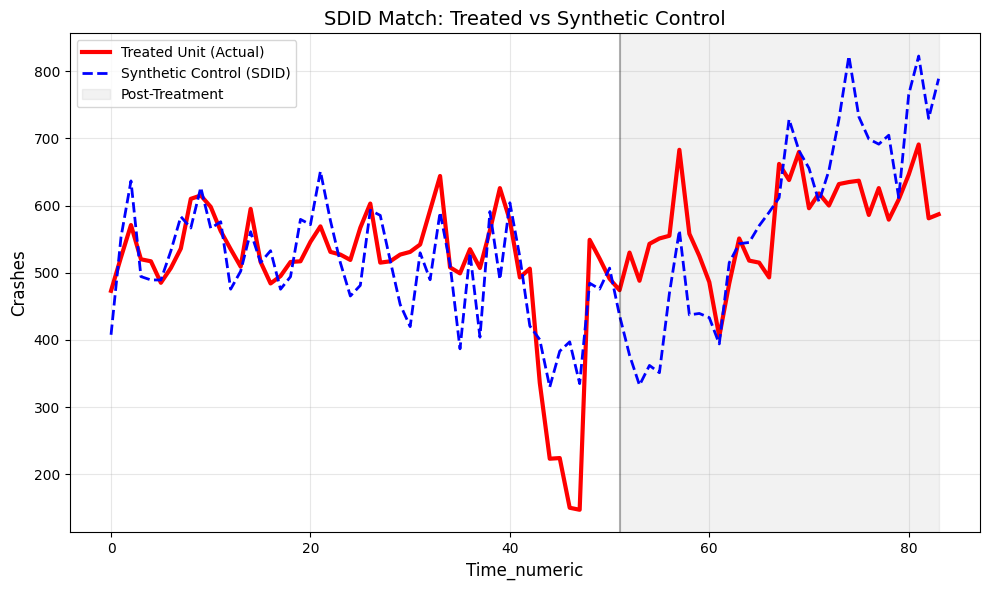

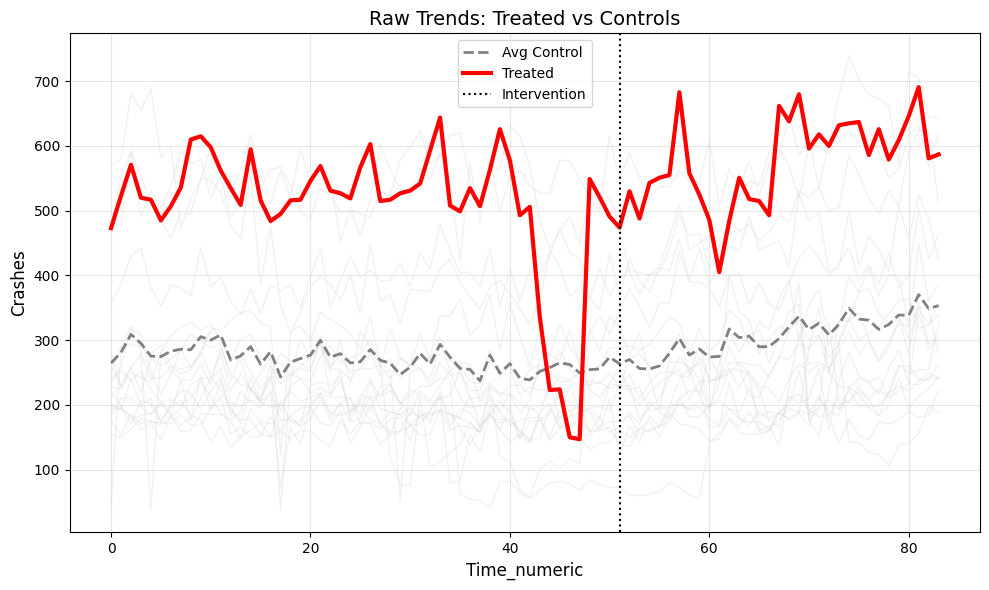

In [ ]:
# 1. Synthetic control vs actual SF trends
model.plot_synthetic_control()

# 2. Raw trends for all cities
model.plot_raw_trends()

# Also print the full summary
model.summary()

In [ ]:
model.estimate_se(n_bootstrap=200, n_jobs=4)
print(model.summary(confidence_level = .95))

Synthetic Difference-in-Differences Results
Treatment Effect (ATT): 171.7879
Standard Error:        78.1205
95% Confidence Interval: [18.6746, 324.9012]
t-statistic:           2.1990
p-value:               0.0279
Control units used:    6
Time periods used:     0


In [ ]:
model.get_weights_summary()

{'unit_weights':                 weight  rank
 Agency                      
 Long Beach    1.130991   1.0
 Pasadena      0.841860   2.0
 Garden Grove  0.521374   3.0
 Riverside     0.508788   4.0
 Fresno        0.289043   5.0
 Stockton      0.074993   6.0,
 'time_weights': Empty DataFrame
 Columns: [weight, rank]
 Index: []}